# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

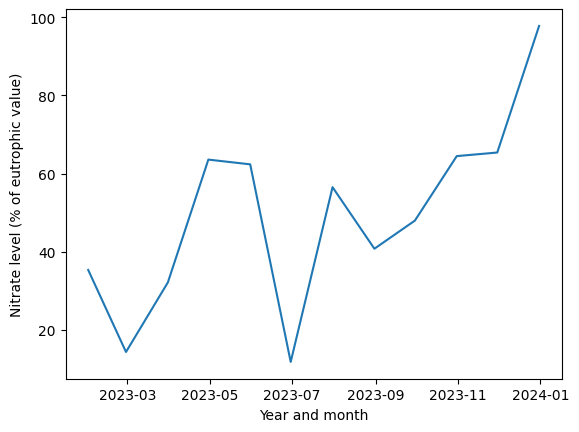

In [4]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

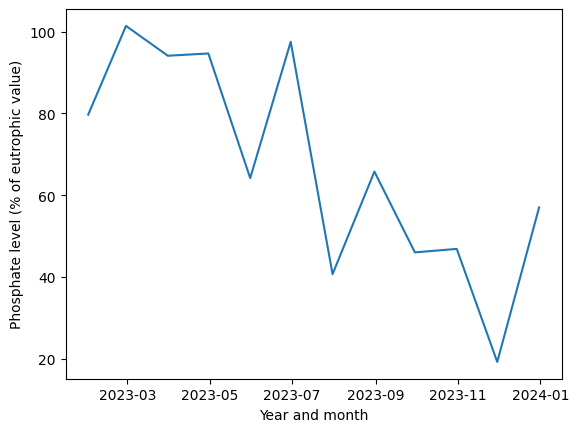

In [5]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

Preattentive Attributes - Suggestions

- You could bold the last three months on the plot to guide the user towards that section of the graph
- You could change the color of the line plot for the last 3 months so it stands out more. For example, make the other parts of the graph grey or a neutral tone and then make the last 3 months red or a bold blue that immediately stands out
- Color code the last three months on the x axis to match the color of the lines for those months. Keep the rest of the graph in a more dull, neutral tone.

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

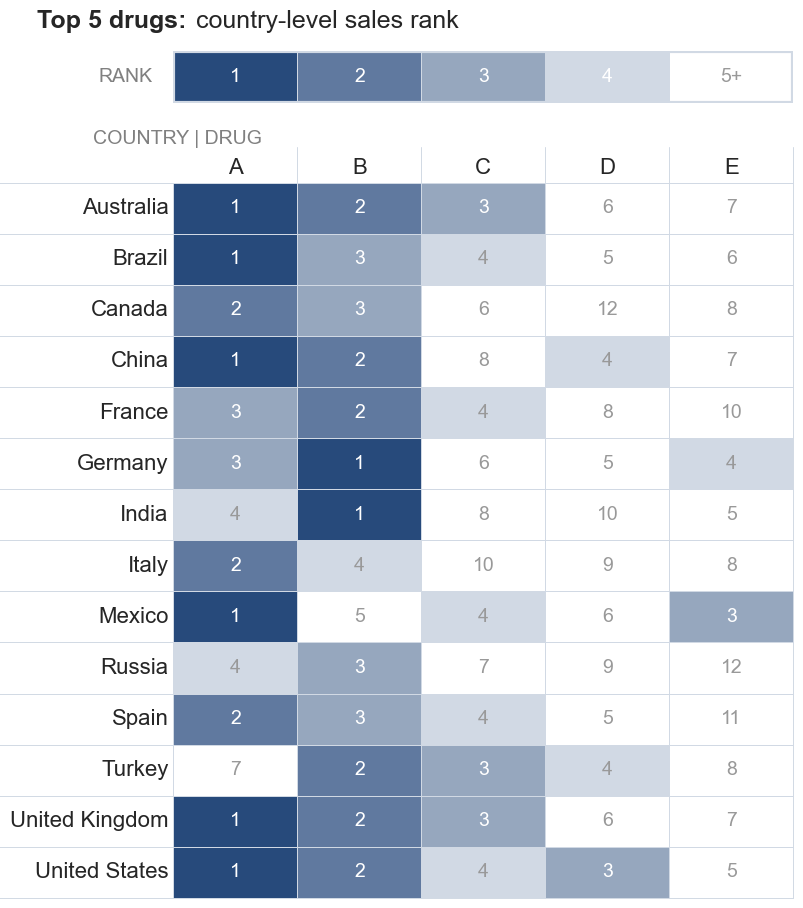

In [91]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle


hex_codes = ["#274a7b", "#60799f", "#96a7be", "#d1d9e4", "#FFFFFF"]
cmap = ListedColormap(hex_codes)

data = {        # AUS    BRA    CAN    CHI    FRA    GER    IND    ITA    MEX    RUS    SPA    TUR    UK    USA
    'A':        [1,      1,     2,     1,     3,     3,     4,     2,     1,     4,     2,     7,     1,    1],
    'B':        [2,      3,     3,     2,     2,     1,     1,     4,     5,     3,     3,     2,     2,    2],
    'C':        [3,      4,     6,     8,     4,     6,     8,     10,    4,     7,     4,     3,     3,    4],
    'D':        [6,      5,     12,    4,     8,     5,     10,    9,     6,     9,     5,     4,     6,    3],
    'E':        [7,      6,     8,     7,     10,    4,     5,     8,     3,     12,    11,    8,     7,    5]
}

df = pd.DataFrame(data, columns=['A', 'B', 'C', 'D', 'E'], index=['Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'India', 'Italy', 'Mexico', 'Russia', 'Spain', 'Turkey', 'United Kingdom', 'United States'])

def map_ranks_to_color_index(val):

    # Rank is 1-4, get the color index
    if val <= 4:
        return val - 1
    
    # Rank is above 4, get the white index (4)
    else:
        return 4
    
color_data = df.map(map_ranks_to_color_index)

# Set up grid space for the main heat map and the legend
fig = plt.figure(figsize=(8,10))
gs = fig.add_gridspec(2, 1, height_ratios=[1,20], hspace=0.05)
ax_leg = fig.add_subplot(gs[0])
ax_main = fig.add_subplot(gs[1])

sns.heatmap(
    color_data,
    annot=df,                               # uses original df data for the rank numbers
    fmt="d",                                # integer format
    cmap=cmap,
    cbar=False,                             # hide default color bar
    linewidths=0.7,                         # thin lines between cells
    linecolor="#d1d9e4",
    annot_kws={"size": 14},                 # adjust size of the numbers in the cells
    ax=ax_main
)

# Handle coloring scheme for text in the blue and white cells
for text in ax_main.texts:
    val = int(text.get_text())
    if val <= 3:
        text.set_color("white")
    else:
        text.set_color("#999999")

ax_main.xaxis.tick_top()                     # moving A, B, C, D, E to the top of the chart
ax_main.xaxis.set_label_position('top')

# COUNTRY | DRUG subtitle
ax_main.text(-0.65, -0.75, 'COUNTRY | DRUG', color='grey', fontsize=14)
ax_main.tick_params(axis='x', labelsize=16, length=0) # Size of A, B, C, D, E
ax_main.tick_params(axis='y', labelsize=16, length=0) # Size of Australia, Brazil, etc.

# draw lines that start to the left of the 0 axis
for i in range(len(df) + 1):
    ax_main.axhline(i, color='#d1d9e4', linewidth=0.7, clip_on=False, xmin=-0.4)

# draw lines for the drug column
for i in range(1, len(df.columns) + 1):
    ax_main.axvline(i, color='#d1d9e4', linewidth=0.7, clip_on=False, ymin=0, ymax=1.05)

# RANK Legend
legend_vals = np.array([[0,1,2,3,4]])
legend_labels = ['1', '2', '3', '4','5+']

sns.heatmap(
    legend_vals, 
    cmap=cmap, 
    cbar=False, 
    linewidths=0.7, 
    linecolor="#d1d9e4", 
    ax=ax_leg
)


ax_leg.add_patch(Rectangle((0, 0), 5, 1, fill=False, edgecolor='#d1d9e4', lw=3))

# Add text to legend boxes
for i, label in enumerate(legend_labels):
    ax_leg.text(i + 0.5, 0.5, label, ha='center', va='center', 
                color="white" if i <= 3 else "#999999", fontsize=14)

# Align legend with the main heat map
main_pos = ax_main.get_position()
row_height = main_pos.height / len(df)
ax_leg.set_position([main_pos.x0, main_pos.y1 + 0.08, main_pos.width, row_height])

ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_ylabel('RANK', rotation=0, va='center', ha='right', labelpad=15, color='grey', fontsize=14)

# Title
fig.text(main_pos.x0 - 0.17, 0.98, "Top 5 drugs:", 
         fontsize=18, fontweight='bold', ha='left')

fig.text(main_pos.x0 + 0.02, 0.98, " country-level sales rank", 
         fontsize=18, fontweight='normal', ha='left')

sns.despine(left=True, right=True, top=True, bottom=True)
plt.show()